In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet


In [5]:
# 2. LOAD DATA

import pandas as pd
df = pd.read_csv("GlobalWeatherRepository.csv")

In [6]:
print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.info())
print(df.isnull().sum())

Shape: (136048, 41)
Columns: Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136048 entries, 0 to 136047
Data columns (total 41 columns):
 #   Column                        Non-Null

In [8]:
# 3. DATA CLEANING

# Convert date column
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Handle missing values
# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Drop remaining nulls
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

/tmp/ipykernel_15619/1119063747.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [9]:
# 4. OUTLIER HANDLING

# Using IQR method
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
df = df[(df['temperature_celsius'] >= lower_bound) &
        (df['temperature_celsius'] <= upper_bound)]

In [10]:
# 5. NORMALIZATION

scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


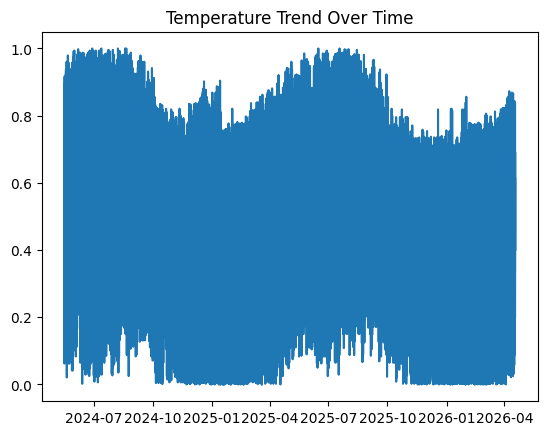

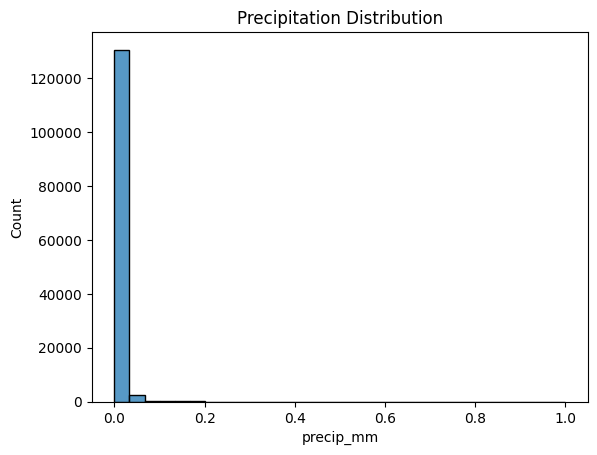

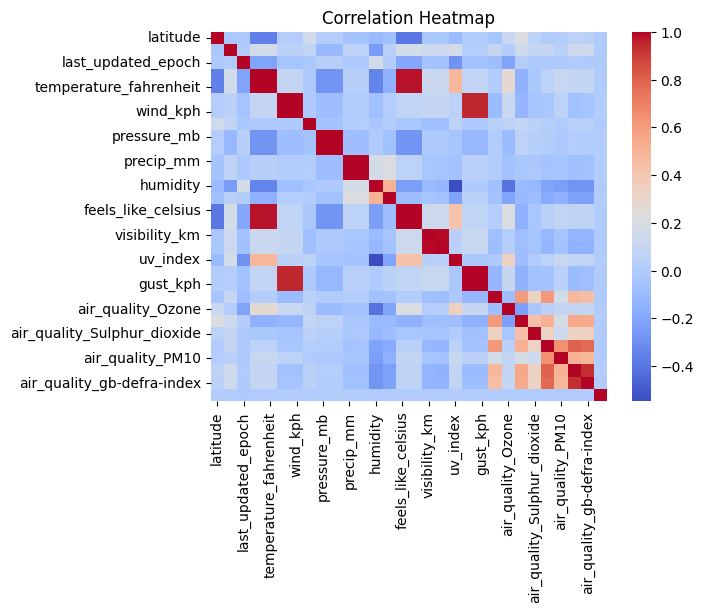

In [11]:
# 6. BASIC EDA

# Temperature over time
plt.figure()
df_sorted = df.sort_values('last_updated')
plt.plot(df_sorted['last_updated'], df_sorted['temperature_celsius'])
plt.title("Temperature Trend Over Time")
plt.show()

# Precipitation distribution
plt.figure()
sns.histplot(df['precip_mm'], bins=30)
plt.title("Precipitation Distribution")
plt.show()

# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# 7. TIME SERIES PREP

df_ts = df[['last_updated', 'temperature_celsius']]
df_ts = df_ts.sort_values('last_updated')
df_ts.set_index('last_updated', inplace=True)

# Train/Test split
train_size = int(len(df_ts) * 0.8)
train = df_ts[:train_size]
test = df_ts[train_size:]

In [13]:
#8. MODEL 1: ARIMA

arima_model = ARIMA(train, order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [14]:
#9. MODEL 2: PROPHET

prophet_df = df_ts.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

prophet_pred = forecast['yhat'][-len(test):].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [15]:
#10. MODEL 3: RANDOM FOREST

# Feature engineering
df_rf = df.copy()
df_rf['year'] = df_rf['last_updated'].dt.year
df_rf['month'] = df_rf['last_updated'].dt.month

y = df_rf['temperature_celsius']
X = df_rf.select_dtypes(include=np.number).drop(columns=['temperature_celsius'])

rf = RandomForestRegressor()
rf.fit(X, y)

rf_pred = rf.predict(X[-len(test):])

In [16]:
# 11. ENSEMBLE MODEL

ensemble_pred = (arima_pred.values + prophet_pred + rf_pred) / 3

In [17]:
# 12. EVALUATION

def evaluate(true, pred, name):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} MAE:", mae)

print("\n--- Model Evaluation ---")
evaluate(test.values, arima_pred, "ARIMA")
evaluate(test.values, prophet_pred, "Prophet")
evaluate(test.values, rf_pred, "Random Forest")
evaluate(test.values, ensemble_pred, "Ensemble")


--- Model Evaluation ---
ARIMA RMSE: 0.19951626185878443
ARIMA MAE: 0.16543662159959804
Prophet RMSE: 1.6026793215593862
Prophet MAE: 1.4063677334215168
Random Forest RMSE: 0.2750609489545004
Random Forest MAE: 0.21915709979916714
Ensemble RMSE: 0.5763388605356153
Ensemble MAE: 0.4916937733286259


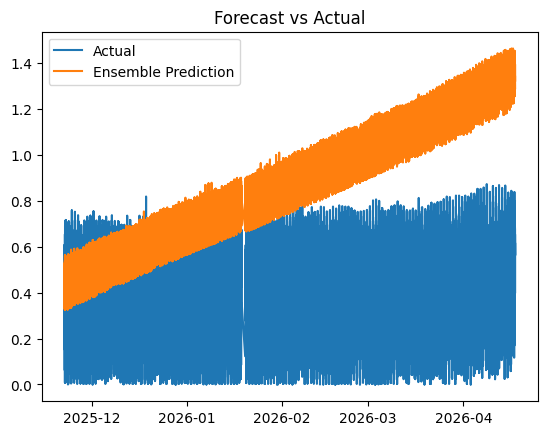

In [18]:
# 13. VISUALIZATION

plt.figure()
plt.plot(test.index, test.values, label='Actual')
plt.plot(test.index, ensemble_pred, label='Ensemble Prediction')
plt.legend()
plt.title("Forecast vs Actual")
plt.show()


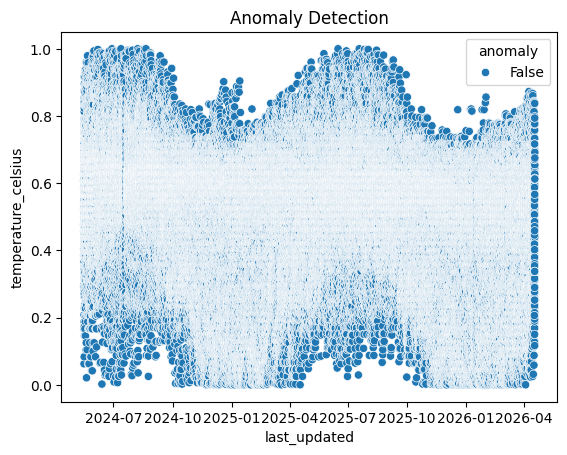

In [19]:
# 14. ANOMALY DETECTION

mean = df['temperature_celsius'].mean()
std = df['temperature_celsius'].std()

df['anomaly'] = np.abs(df['temperature_celsius'] - mean) > 3 * std

plt.figure()
sns.scatterplot(x=df['last_updated'], y=df['temperature_celsius'], hue=df['anomaly'])
plt.title("Anomaly Detection")
plt.show()


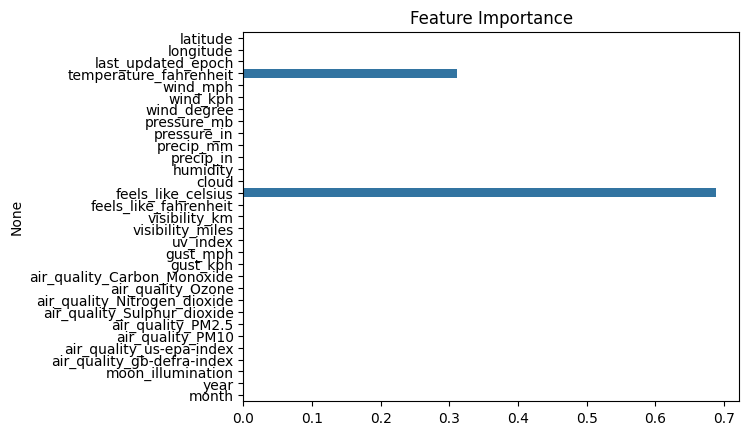

In [20]:
# 15. FEATURE IMPORTANCE

importances = rf.feature_importances_
features = X.columns

plt.figure()
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

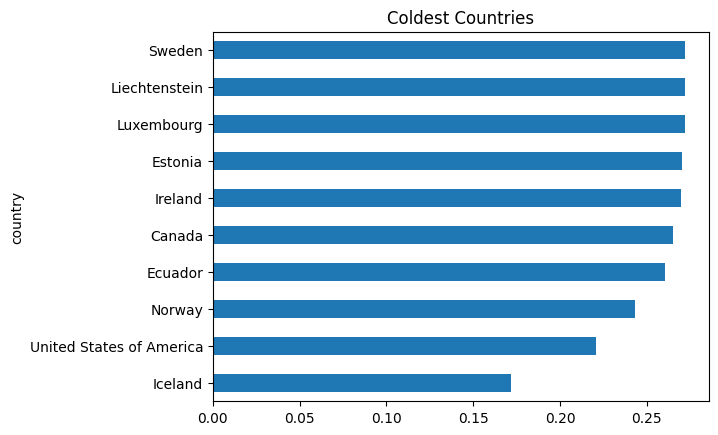

In [21]:
# 16. CLIMATE ANALYSIS

country_temp = df.groupby('country')['temperature_celsius'].mean().sort_values()

plt.figure()
country_temp.head(10).plot(kind='barh')
plt.title("Coldest Countries")
plt.show()

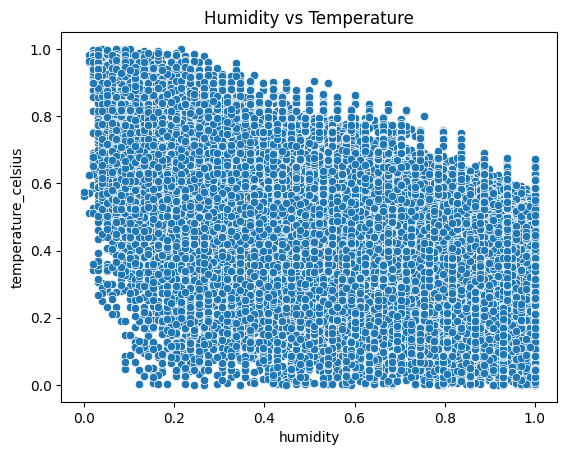

In [22]:
# 17. ENVIRONMENTAL IMPACT

plt.figure()
sns.scatterplot(x='humidity', y='temperature_celsius', data=df)
plt.title("Humidity vs Temperature")
plt.show()

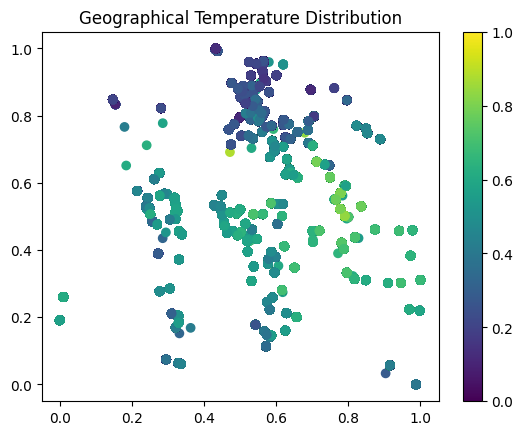

In [23]:
# 18. SPATIAL ANALYSIS

plt.figure()
plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'])
plt.colorbar()
plt.title("Geographical Temperature Distribution")
plt.show()

In [24]:
# 19. GEOGRAPHICAL PATTERNS

continent_temp = df.groupby('country')['temperature_celsius'].mean()

print("\nGeographical Temperature Patterns:")
print(continent_temp.head(10))


Geographical Temperature Patterns:
country
Afghanistan            0.438171
Albania                0.445355
Algeria                0.466266
Andorra                0.275490
Angola                 0.585801
Antigua and Barbuda    0.590390
Argentina              0.355527
Armenia                0.406998
Australia              0.361572
Austria                0.318036
Name: temperature_celsius, dtype: float64
